In [29]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf
import pandas as pd
import importlib
from pathlib import Path
from scipy.stats import zscore
from matplotlib.colors import Normalize
from matplotlib import cm
repo_root = Path('.').resolve()
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import src.generate
importlib.reload(src.generate)
from src.generate import generate_varma, generate_gbm
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_mts_heatmap, scale_mts_heatmap
from src.plot_style import save_figure
from importlib import reload
import src.visualization
reload(src.visualization)
from src.visualization import plot_mts_heatmap, scale_mts_heatmap

from src.plot_style import apply_plot_style
apply_plot_style()

output_dir = repo_root / 'figures' 
output_dir.mkdir(parents=True, exist_ok=True)
output_dir

dpi=600

##### Kuramoto

In [25]:
M, T = 5, 1000
dt: float = 0.01 # Standard dt
K: float = -4.0   # Coupling strength
topology: str = "all-to-all" # 'all-to-all', 'ring-symmetric', 'ring-unidirectional'
omega_mean: float = 1.0
omega_std: float = 0.1
noise_std: float = 0.05 # Dynamic noise (eta)

kur_dat = generate_kuramoto(M=M, T=T, topology=topology, dt=dt, K=K,
                        omega_mean=omega_mean, omega_std=omega_std,
                        noise_std=noise_std, transients=100, zscore=True)
np.save(output_dir / 'kur_timeseries.npy', kur_dat)

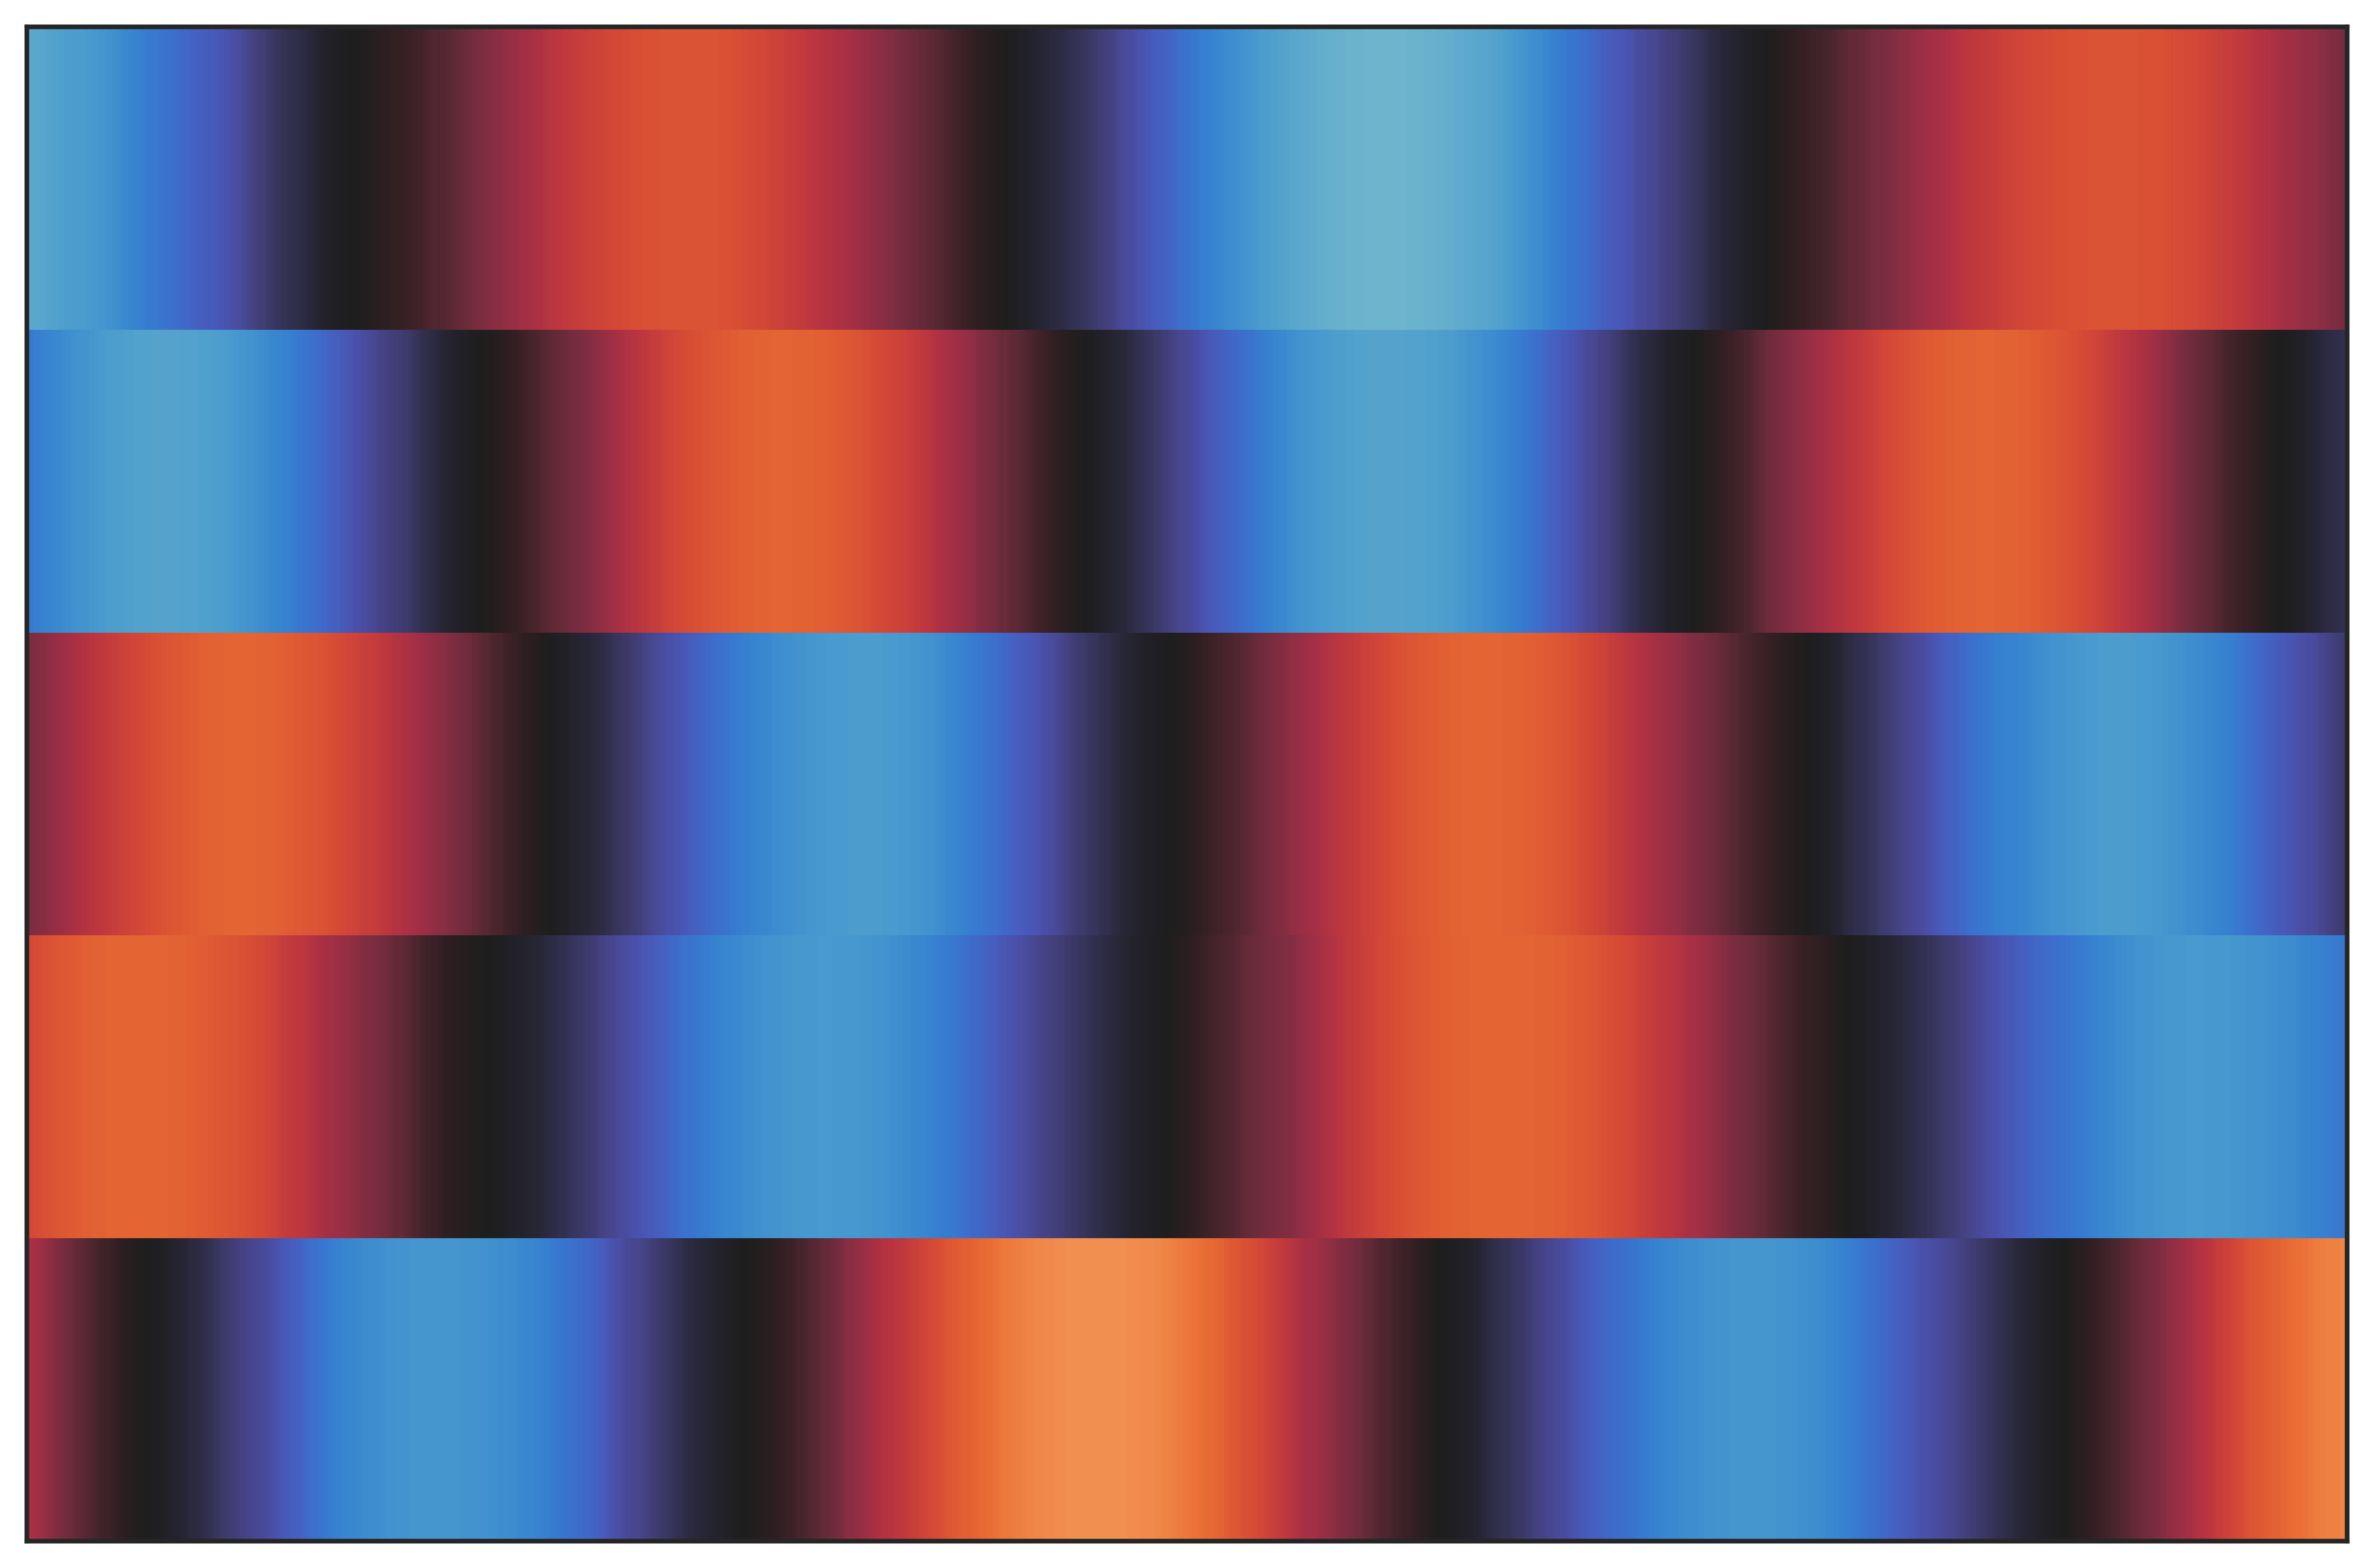

[WindowsPath('figures/kur_timeseries_scaled.svg')]

In [ ]:
plot_mts_heatmap(kur_dat, vmin=-2, vmax=2)
scaled_paths = scale_mts_heatmap(output_dir, filename='kur_timeseries.npy', dpi=dpi)

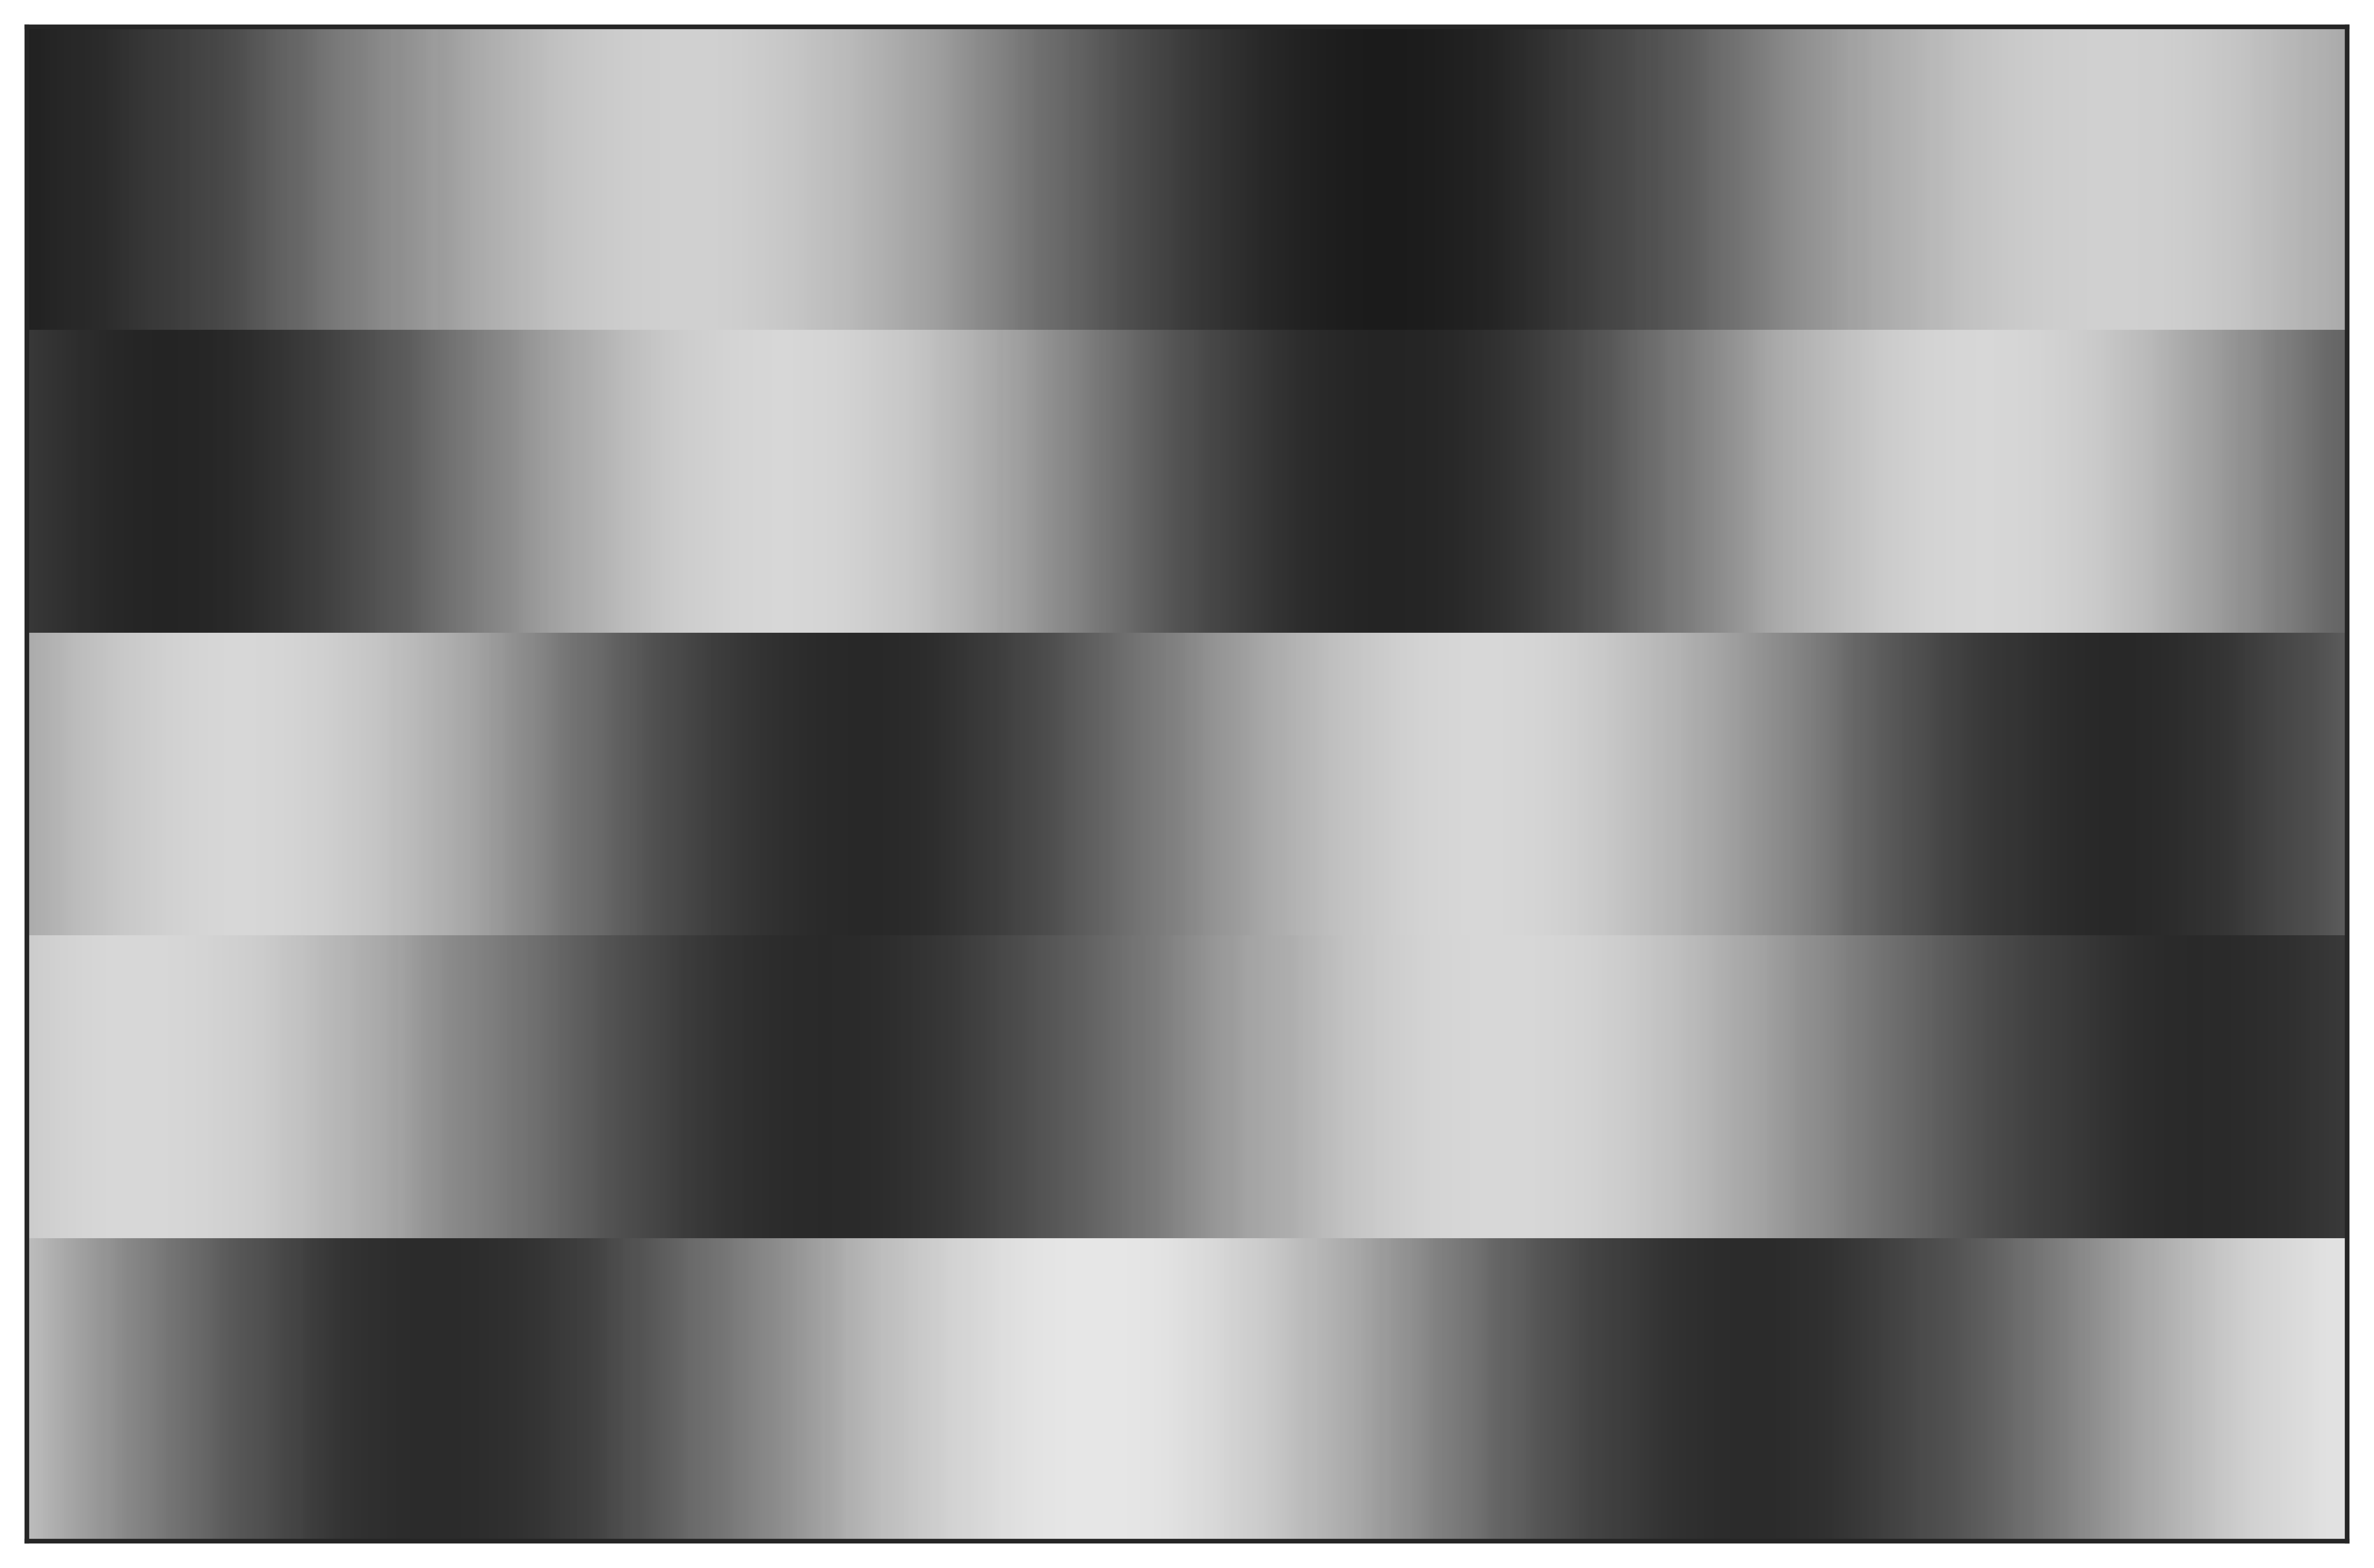

In [32]:
kurg_dat = generate_kuramoto(M=M, T=T, topology=topology, dt=dt, K=K,
                        omega_mean=omega_mean, omega_std=omega_std,
                        noise_std=noise_std, transients=100, zscore=True)
np.save(output_dir / 'kur_gray_timeseries.npy', kurg_dat)

plot_mts_heatmap(kurg_dat, cmap="gray", vmin=-2, vmax=2)
scaled_paths = scale_mts_heatmap(output_dir, cmap="gray", filename='kur_gray_timeseries.npy', dpi=dpi)


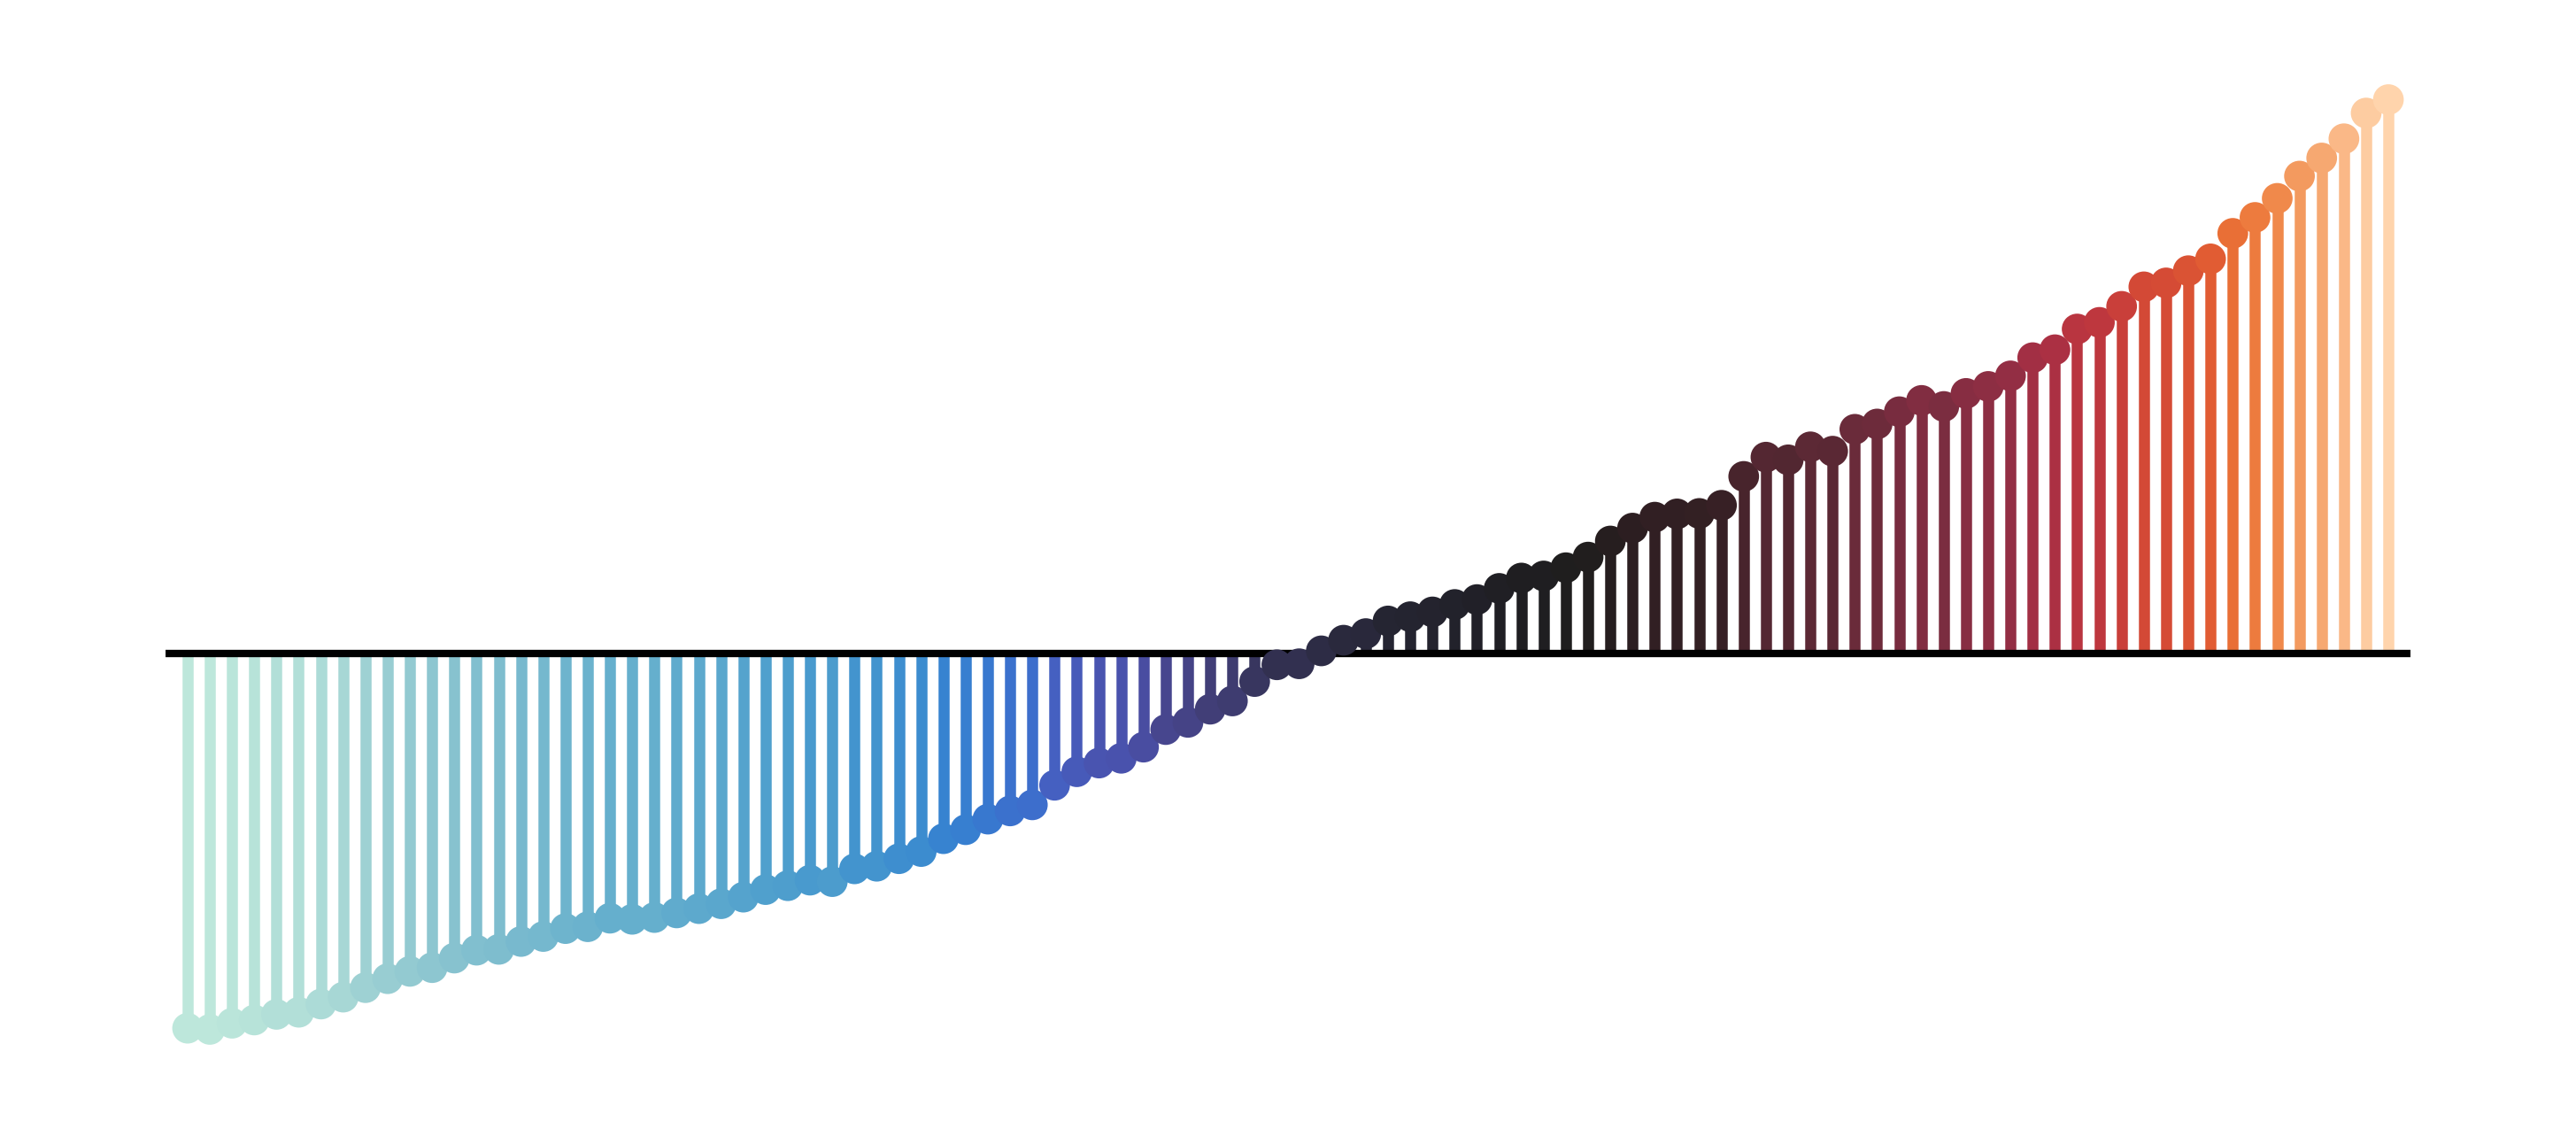

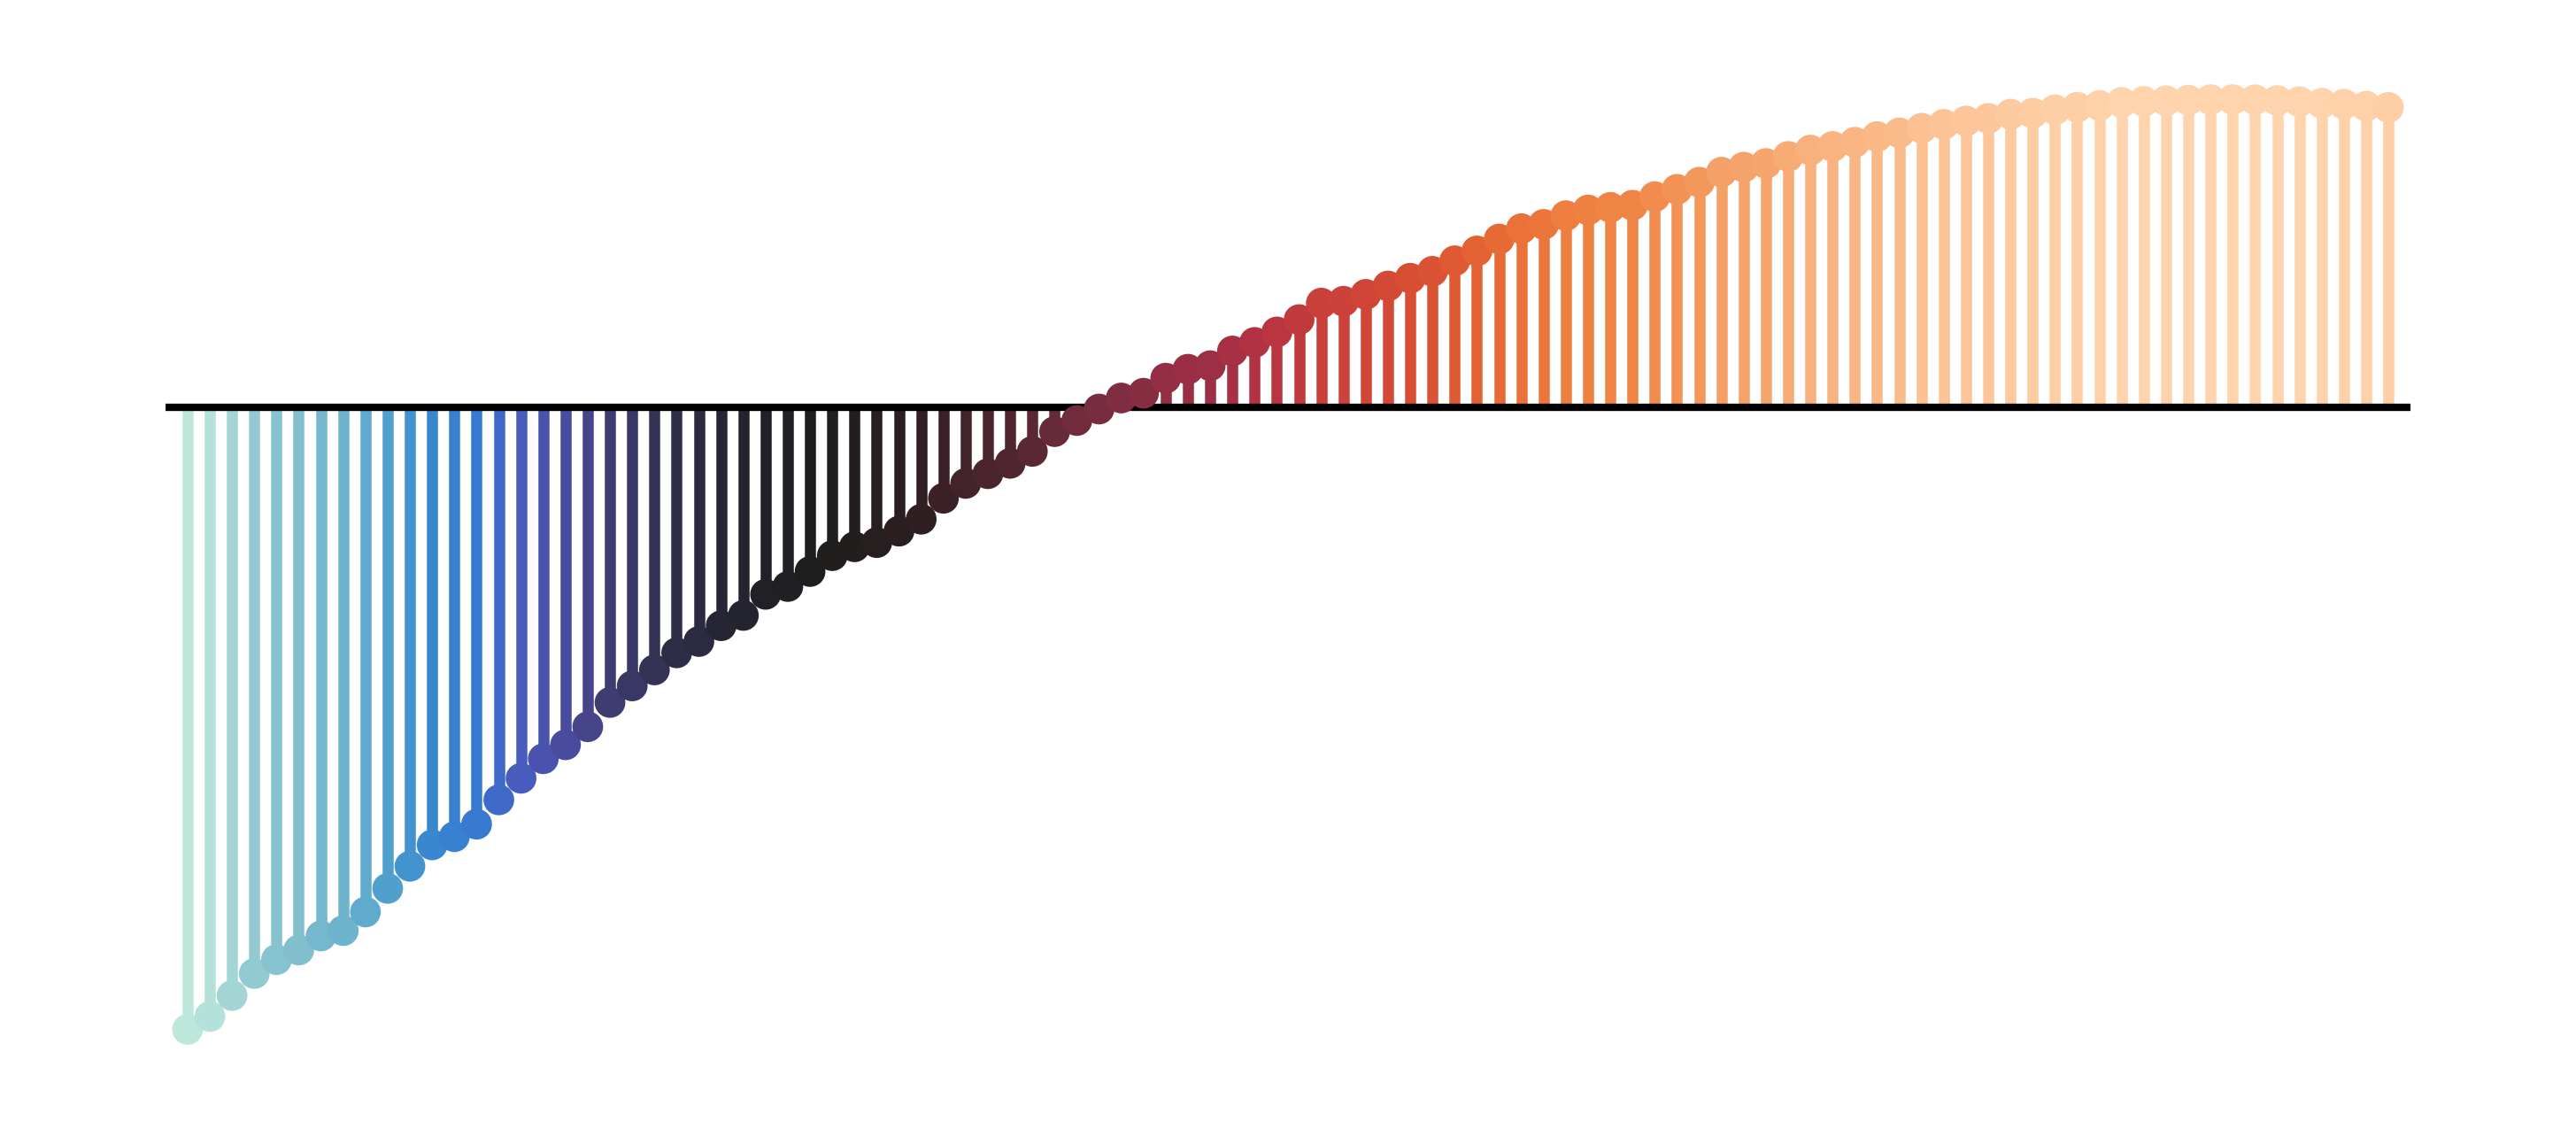

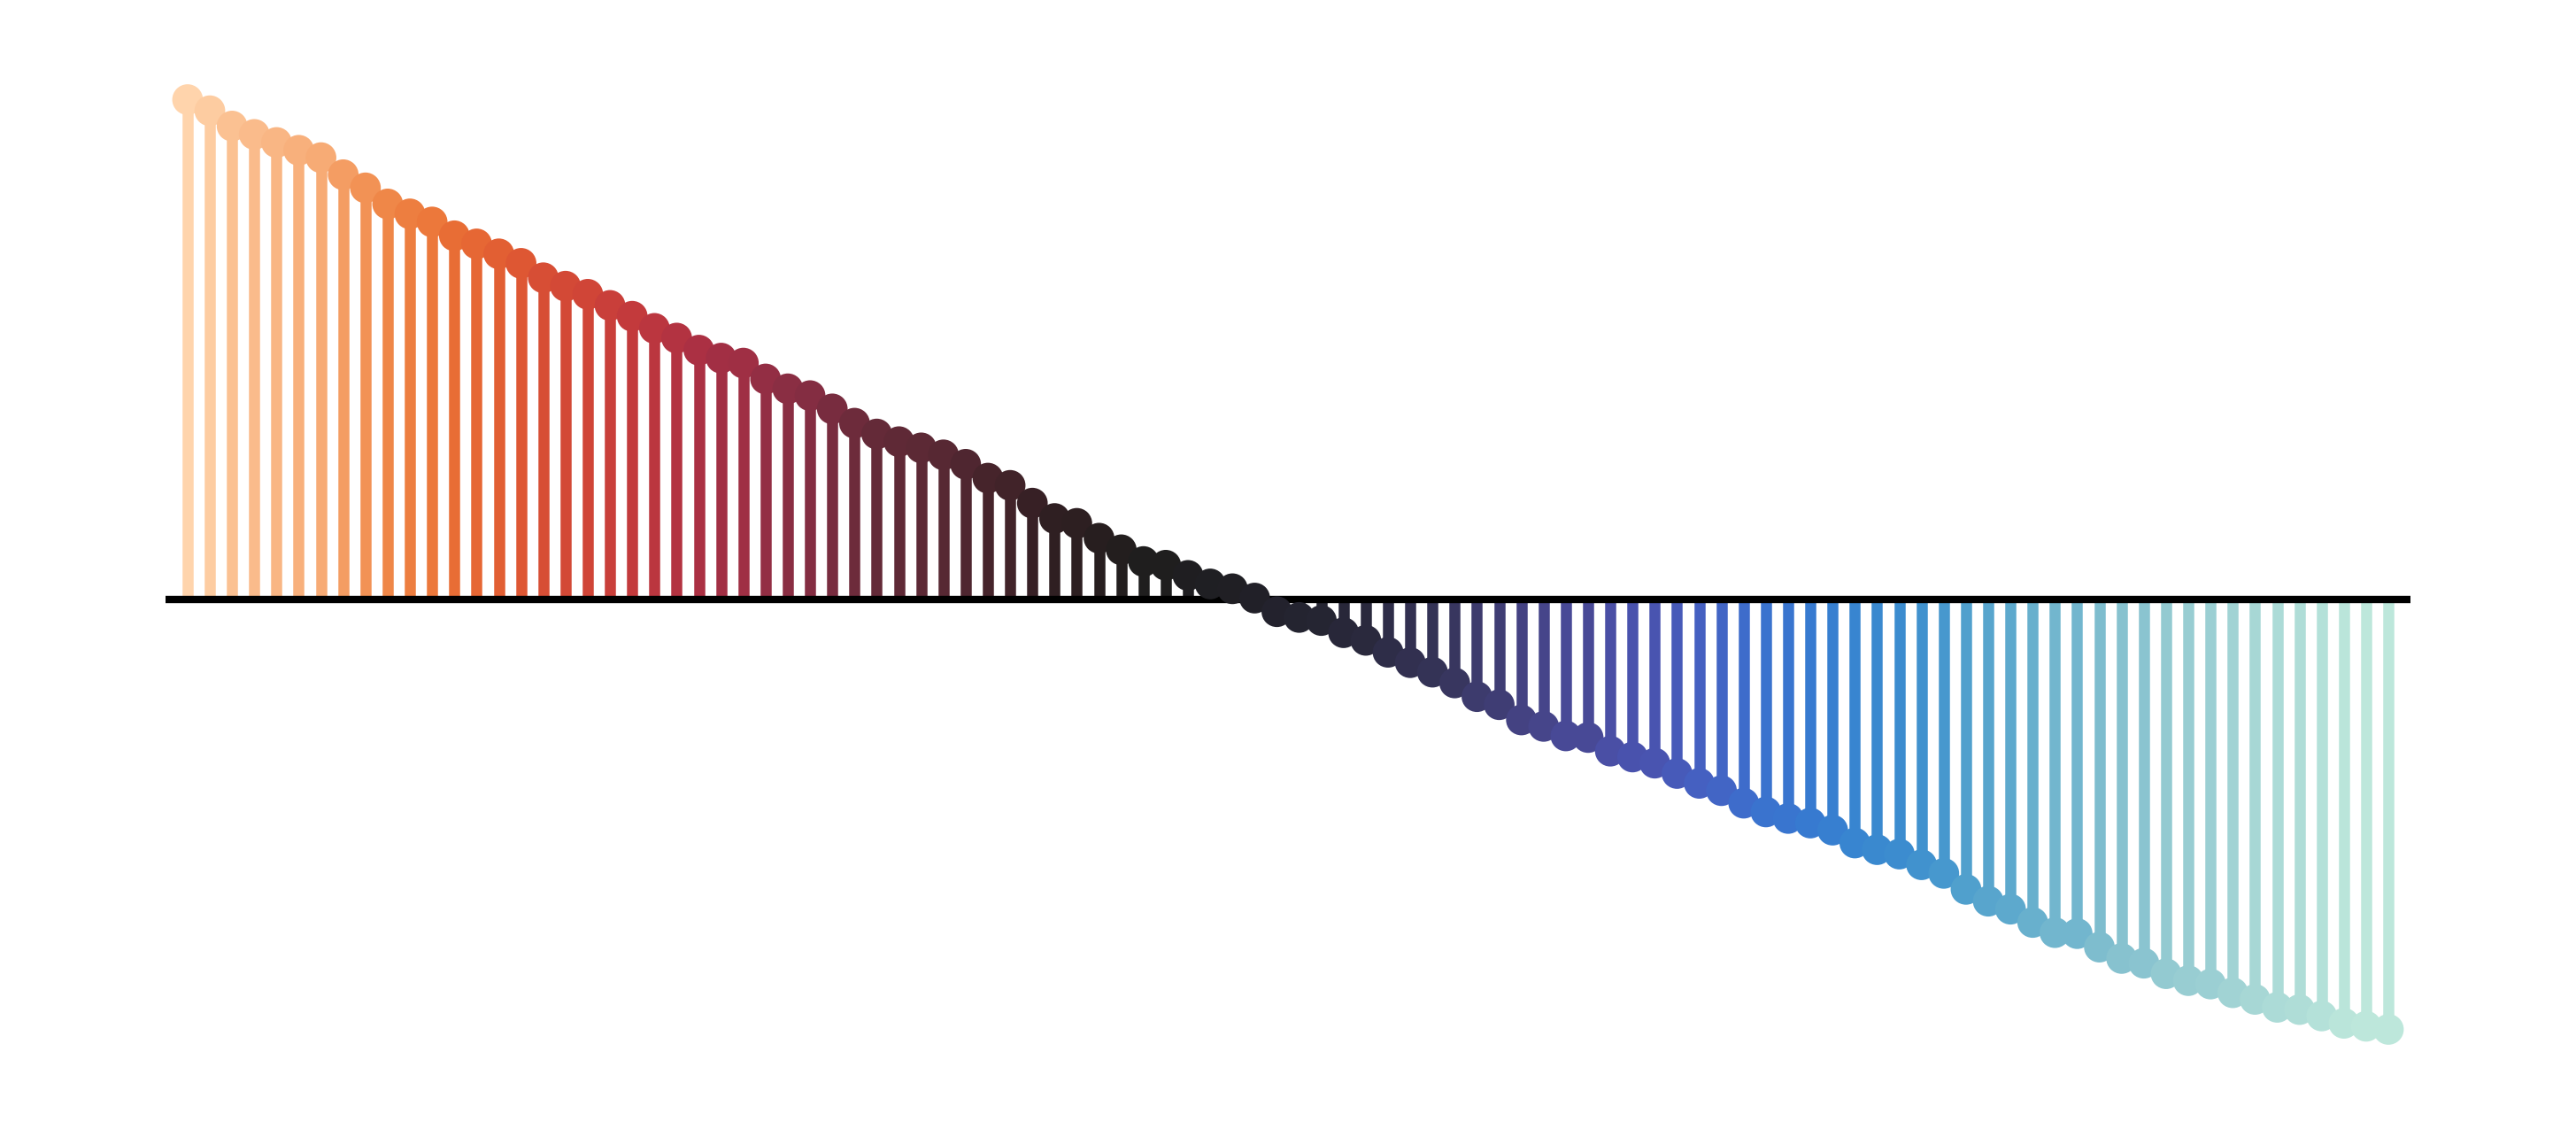

(<Figure size 3600x1500 with 1 Axes>, <Axes: >)

In [18]:
def plot_stems(series: np.ndarray, name: str, output_dir: Path, *, ax=None):
    vals = np.asarray(series, dtype=float).reshape(-1)
    xs = np.arange(vals.size)
    cmap = sns.color_palette("icefire", as_cmap=True)
    colors = cmap((vals - vals.min()) / (vals.ptp() or 1.0))
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 2.5), dpi=dpi)
    else:
        fig = ax.figure
    ax.vlines(xs, 0.0, vals, colors=colors, linewidth=1.5)
    ax.hlines(0.0, xs[0]-1, xs[-1]+1, colors="black", linewidth=1.0)
    ax.scatter(xs, vals, c=colors, s=10, zorder=3, alpha=1)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.savefig(output_dir / f"{name}.svg", transparent=True)
    ax.axis("off")
    plt.show()
    # plt.close()
    return fig, ax

output_dir = Path("figures")

plot_stems(mts[:, 4], "stems_kur[0]", output_dir)
plot_stems(mts[:, 2], "stems_kur[2]", output_dir)
plot_stems(mts[:, 0], "stems_kur[4]", output_dir)

##### Next

##### Next 2